In [2]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Install seaborn if not already installed
# pip install seaborn

# Val transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder("data/val", transform=val_transforms)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False)

classes = val_dataset.classes
print("Classes:", classes)
print("Val images:", len(val_dataset))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Val images: 508


In [3]:
# Load model architecture
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 6)
)

# Load our best trained weights
model.load_state_dict(torch.load("clearbin_best.pth"))
model.eval()

print("Best model loaded!")
print("Ready for evaluation!")

Best model loaded!
Ready for evaluation!


In [4]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

correct = (all_preds == all_labels).sum()
total = len(all_labels)

print(f"Total images evaluated : {total}")
print(f"Correct predictions    : {correct}")
print(f"Wrong predictions      : {total - correct}")
print(f"Overall accuracy       : {100 * correct / total:.1f}%")

Total images evaluated : 508
Correct predictions    : 471
Wrong predictions      : 37
Overall accuracy       : 92.7%


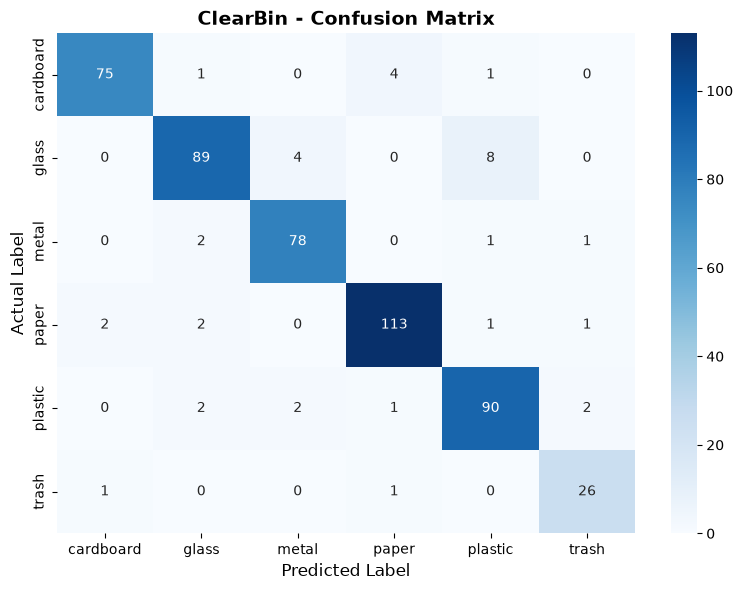

Confusion matrix saved as confusion_matrix.png!


In [5]:
# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title('ClearBin - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as confusion_matrix.png!")

In [6]:
print(classification_report(all_labels, all_preds, 
                            target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.96      0.93      0.94        81
       glass       0.93      0.88      0.90       101
       metal       0.93      0.95      0.94        82
       paper       0.95      0.95      0.95       119
     plastic       0.89      0.93      0.91        97
       trash       0.87      0.93      0.90        28

    accuracy                           0.93       508
   macro avg       0.92      0.93      0.92       508
weighted avg       0.93      0.93      0.93       508



In [7]:
# ============================================
# CLEARBIN - DAY 6 NOTES
# ============================================

# 1. Confusion Matrix
#    - Diagonal = correct predictions
#    - Off diagonal = mistakes
#    - Glass/Plastic confused (both shiny transparent)
#    - Cardboard/Paper confused (similar texture)
#    - Logical mistakes = model learned real features

# 2. Classification Report
#    - Precision : when model predicts X, how often correct
#    - Recall    : out of all real X, how many found
#    - F1 score  : balance of precision and recall
#    - Support   : number of val images per class

# 3. Final Results
#    - Overall accuracy : 92.7%
#    - Best class       : paper (0.95 f1)
#    - Weakest class    : trash (0.90 f1) - least data
#    - All classes above 0.90 f1 - production ready!

# 4. Key insight
#    - Model makes logical mistakes (similar looking items)
#    - Not random errors = model genuinely learned features
#    - Ready for deployment!

print("Day 6 complete! Model evaluated and production ready!")

Day 6 complete! Model evaluated and production ready!


In [ ]:
no lets push day 5 and 6
